# Coursework 1

- Regression problem (predict the popularity of a song).
- Classification problem (predict the top genre a song belongs to).
- Dataset (https://www.kaggle.com/datasets/cnic92/spotify-past-decades-songs-50s10s)

## TODO

- [ ] A description of the selected problem and the motivation

- [ ]  A description of the model and solution that you employed for the final set of  predictions

- [ ] A justification for why you choose this architecture and solution including: how you came up with the approach, why you selected or modified input variables, what worked and did not work, and what other models were tried.

- [ ] All code to reproduce the final predictions must be included, along with any code
supporting/justifying your choices.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("Setup complete.")

Setup complete.


## Step 1: Exploratory Data Analysis

Each subsection investigates a specific aspect of the data, records an observation, and (where relevant) records a cleaning decision. All decisions are applied together at the end of this step.

In [2]:
RAW = Path("../../data/spotify-songs/raw")

decade_map = {
    1950: "1950.csv", 1960: "1960.csv", 1970: "1970.csv",
    1980: "1980.csv", 1990: "1990.csv", 2000: "2000.csv", 2010: "2010.csv",
}

frames = []
for decade, fname in decade_map.items():
    chunk = pd.read_csv(RAW / fname)
    chunk["source_decade"] = decade
    frames.append(chunk)

df = pd.concat(frames, ignore_index=True)

# Normalise column names; drop per-file index column
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.drop(columns=["number"], errors="ignore")

NUMERIC_COLS = ["bpm", "nrgy", "dnce", "db", "live", "val", "dur", "acous", "spch", "pop"]
TARGET = "pop"

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDuplicates (title + artist): {df.duplicated(subset=['title', 'artist']).sum()}")
df.describe().round(1)

Shape: (667, 15)

Columns: ['title', 'artist', 'top_genre', 'year', 'bpm', 'nrgy', 'dnce', 'db', 'live', 'val', 'dur', 'acous', 'spch', 'pop', 'source_decade']

Duplicates (title + artist): 7


,year,bpm,nrgy,dnce,db,live,val,dur,acous,spch,pop,source_decade
count,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0
mean,1995.0,119.1,61.4,60.3,-8.4,18.2,57.3,224.0,29.9,6.2,63.3,1981.1
std,17.8,25.0,21.7,15.1,3.7,14.4,24.4,59.7,28.9,6.2,13.7,19.5
min,1945.0,62.0,6.0,18.0,-24.0,2.0,6.0,98.0,0.0,2.0,26.0,1950.0
25%,1980.0,101.5,45.0,51.0,-11.0,9.0,39.0,185.0,6.0,3.0,56.0,1960.0
50%,1998.0,120.0,64.0,62.0,-8.0,13.0,58.0,218.0,19.0,4.0,66.0,1980.0
75%,2010.0,134.0,79.0,71.0,-6.0,24.0,78.0,254.0,52.0,6.0,73.5,2000.0
max,2019.0,199.0,100.0,96.0,-1.0,93.0,99.0,511.0,100.0,47.0,94.0,2010.0


### Data Quality

Null audit, year coherence check, `pop` outliers, numeric range sanity, and genre cardinality. Findings here feed directly into the cleaning decisions below.

=== Null audit ===
           count  pct
top_genre     16  2.4


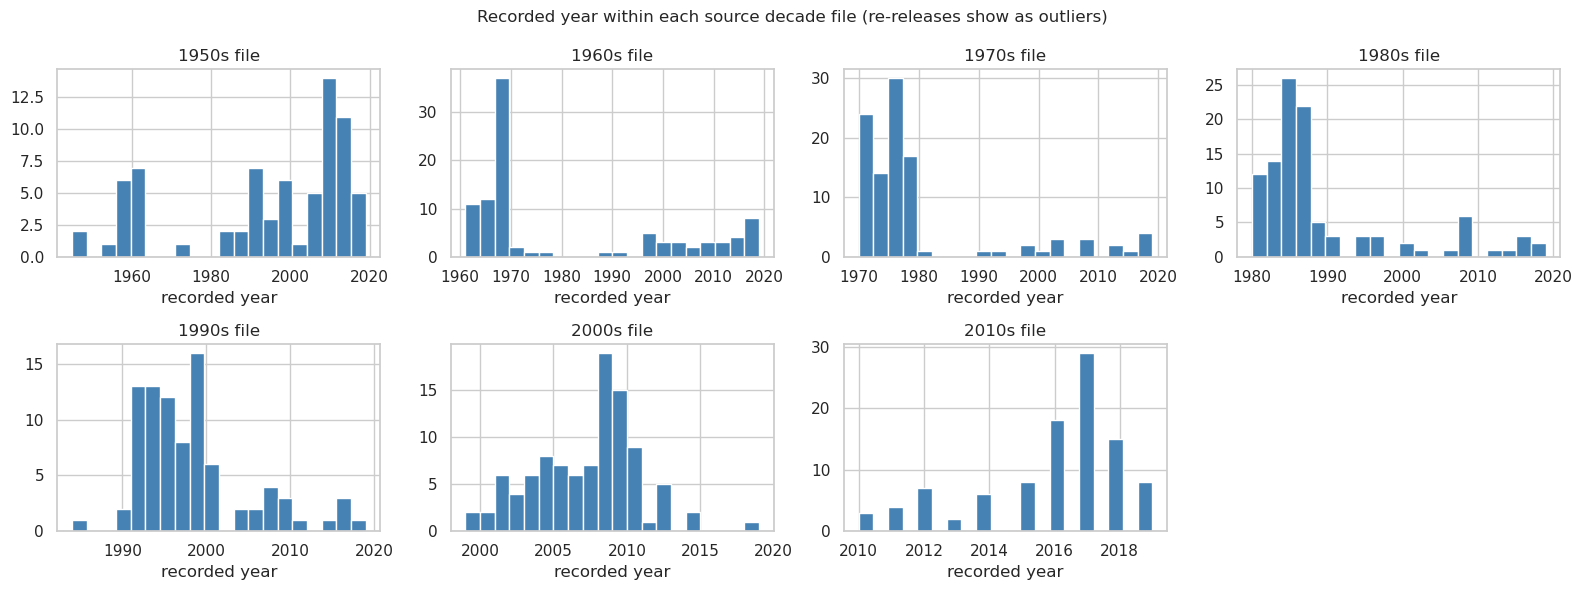

|year − source_decade| > 10: 171 rows
|year − source_decade| > 15: 143 rows
|year − source_decade| > 20: 128 rows

pop == 0 : 0 rows
pop <  5 : 0 rows

=== Numeric ranges ===
       min  max
bpm     62  199
nrgy     6  100
dnce    18   96
db     -24   -1
live     2   93
val      6   99
dur     98  511
acous    0  100
spch     2   47
pop     26   94

Unique genres     : 18
Genres with n=1   : 58
Genres with n<3   : 75

Top 10 genres:
top_genre
dance pop             114
adult standards        93
album rock             77
glam rock              23
brill building pop     20
europop                17
dance rock             15
boy band               15
bubblegum dance        13
big room               13


In [3]:
# ── Null audit ────────────────────────────────────────────────────────────────
null_summary = pd.DataFrame({
    "count": df.isnull().sum(),
    "pct":   (df.isnull().sum() / len(df) * 100).round(1),
})
print("=== Null audit ===")
print(null_summary[null_summary["count"] > 0].to_string() or "  No nulls found")

# ── Year coherence ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, (decade, grp) in zip(axes.flat, df.groupby("source_decade")):
    ax.hist(grp["year"], bins=20, color="steelblue", edgecolor="white")
    ax.set_title(f"{decade}s file")
    ax.set_xlabel("recorded year")
axes.flat[-1].set_visible(False)
fig.suptitle("Recorded year within each source decade file (re-releases show as outliers)", fontsize=12)
plt.tight_layout()
plt.show()

year_gap = (df["year"] - df["source_decade"]).abs()
for threshold in [10, 15, 20]:
    print(f"|year − source_decade| > {threshold}: {(year_gap > threshold).sum()} rows")

# ── pop = 0 / extreme values ──────────────────────────────────────────────────
print(f"\npop == 0 : {(df['pop'] == 0).sum()} rows")
print(f"pop <  5 : {(df['pop'] < 5).sum()} rows")

# ── Numeric range sanity ──────────────────────────────────────────────────────
print("\n=== Numeric ranges ===")
print(df[NUMERIC_COLS].agg(["min", "max"]).T.to_string())

# ── Genre cardinality ─────────────────────────────────────────────────────────
genre_counts = df["top_genre"].value_counts()
print(f"\nUnique genres     : {genre_counts.nunique()}")
print(f"Genres with n=1   : {(genre_counts == 1).sum()}")
print(f"Genres with n<3   : {(genre_counts < 3).sum()}")
print(f"\nTop 10 genres:\n{genre_counts.head(10).to_string()}")

### Distributions

Histograms to check shape, skew table to identify log-transform candidates, box plots by decade to spot temporal drift, and genre frequency to assess encoding strategy.

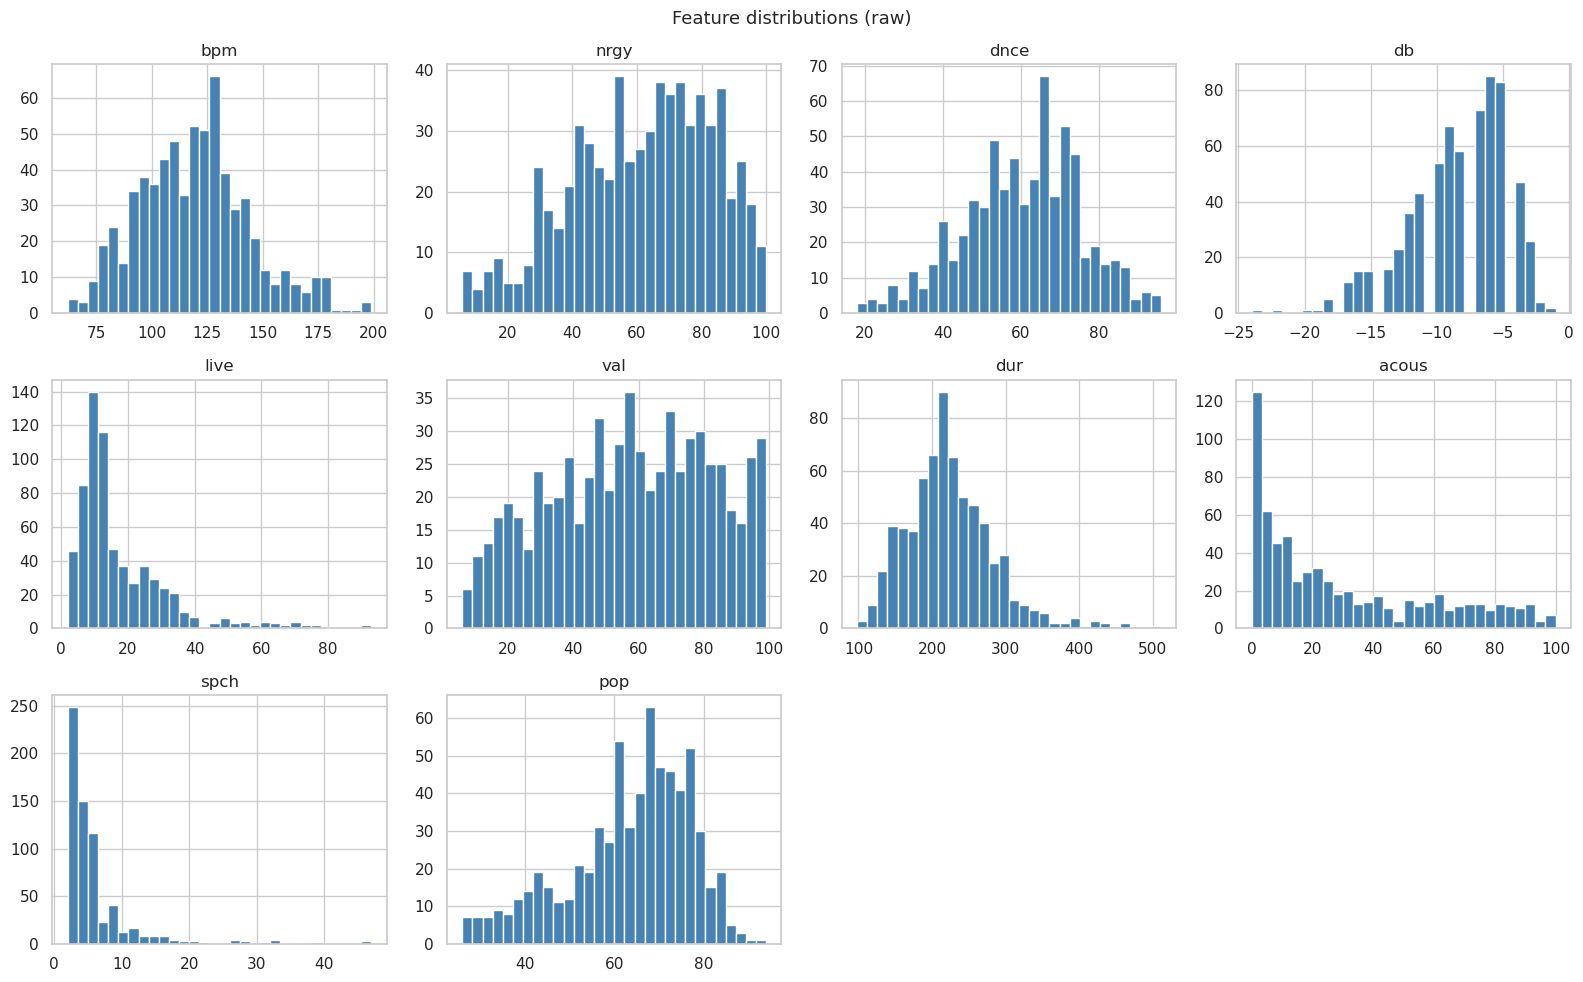

Skewness (|skew| > 1 = candidate for log transform):
spch     3.58
live     2.16
dur      0.97
acous    0.83
db      -0.79
pop     -0.68
nrgy    -0.39
bpm      0.36
dnce    -0.25
val     -0.17


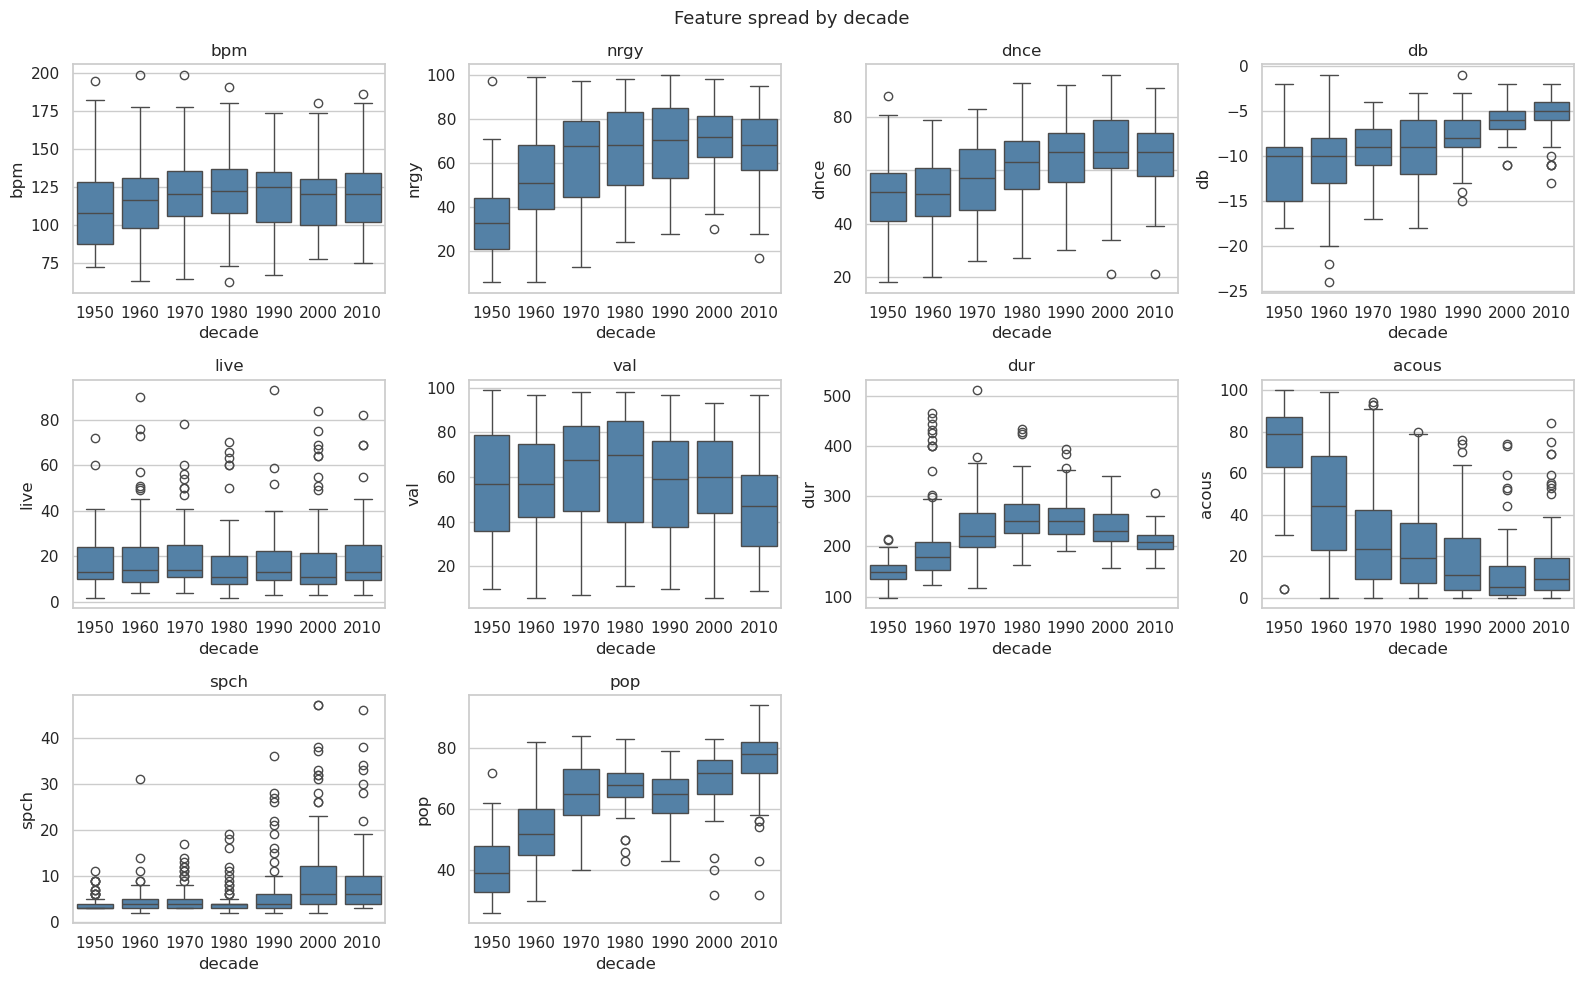

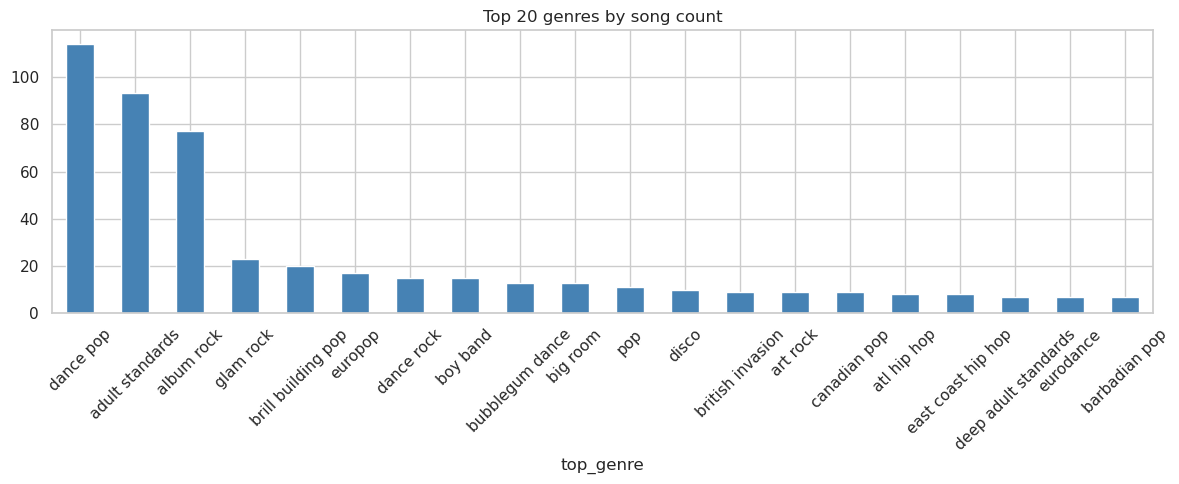

In [4]:
# ── Histograms for all numeric features ──────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.set_visible(False)
fig.suptitle("Feature distributions (raw)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Skew table ────────────────────────────────────────────────────────────────
skew = df[NUMERIC_COLS].skew().rename("skew").round(2)
print("Skewness (|skew| > 1 = candidate for log transform):")
print(skew.sort_values(key=abs, ascending=False).to_string())

# ── Box plots by decade ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.boxplot(data=df, x="source_decade", y=col, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("decade")
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.set_visible(False)
fig.suptitle("Feature spread by decade", fontsize=13)
plt.tight_layout()
plt.show()

# ── Genre frequency ───────────────────────────────────────────────────────────
genre_counts = df["top_genre"].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.head(20).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 genres by song count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Relationships

Correlation with `pop`, scatter plots, and mean `pop` by genre and decade. These drive feature selection and encoding choices in Step 2.

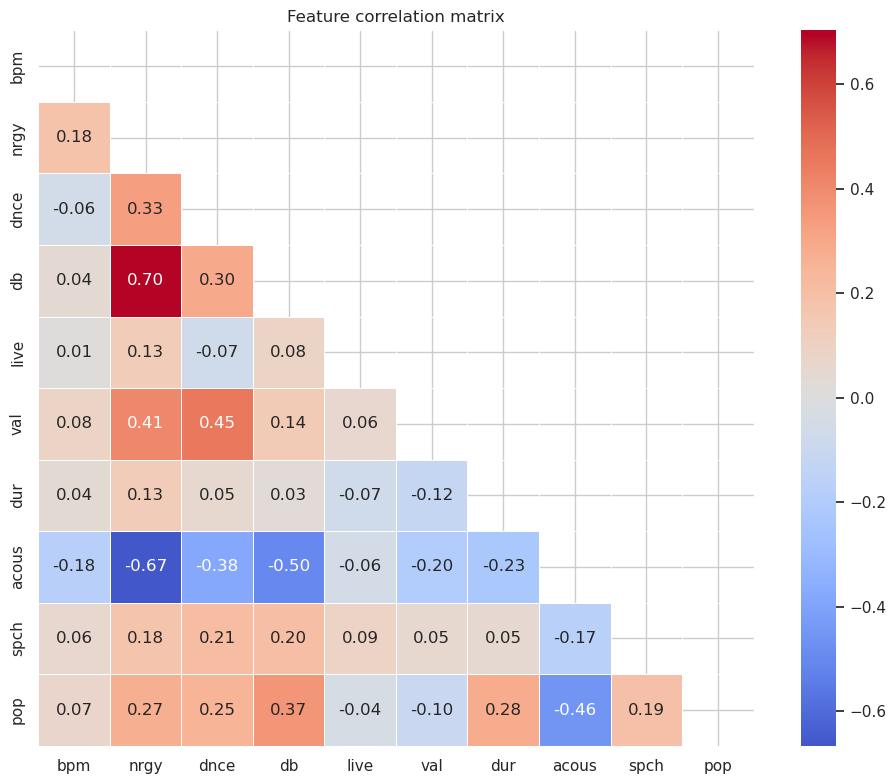

Correlations with pop (sorted):
db       0.365
dur      0.281
nrgy     0.272
dnce     0.249
spch     0.193
bpm      0.067
live    -0.037
val     -0.102
acous   -0.455


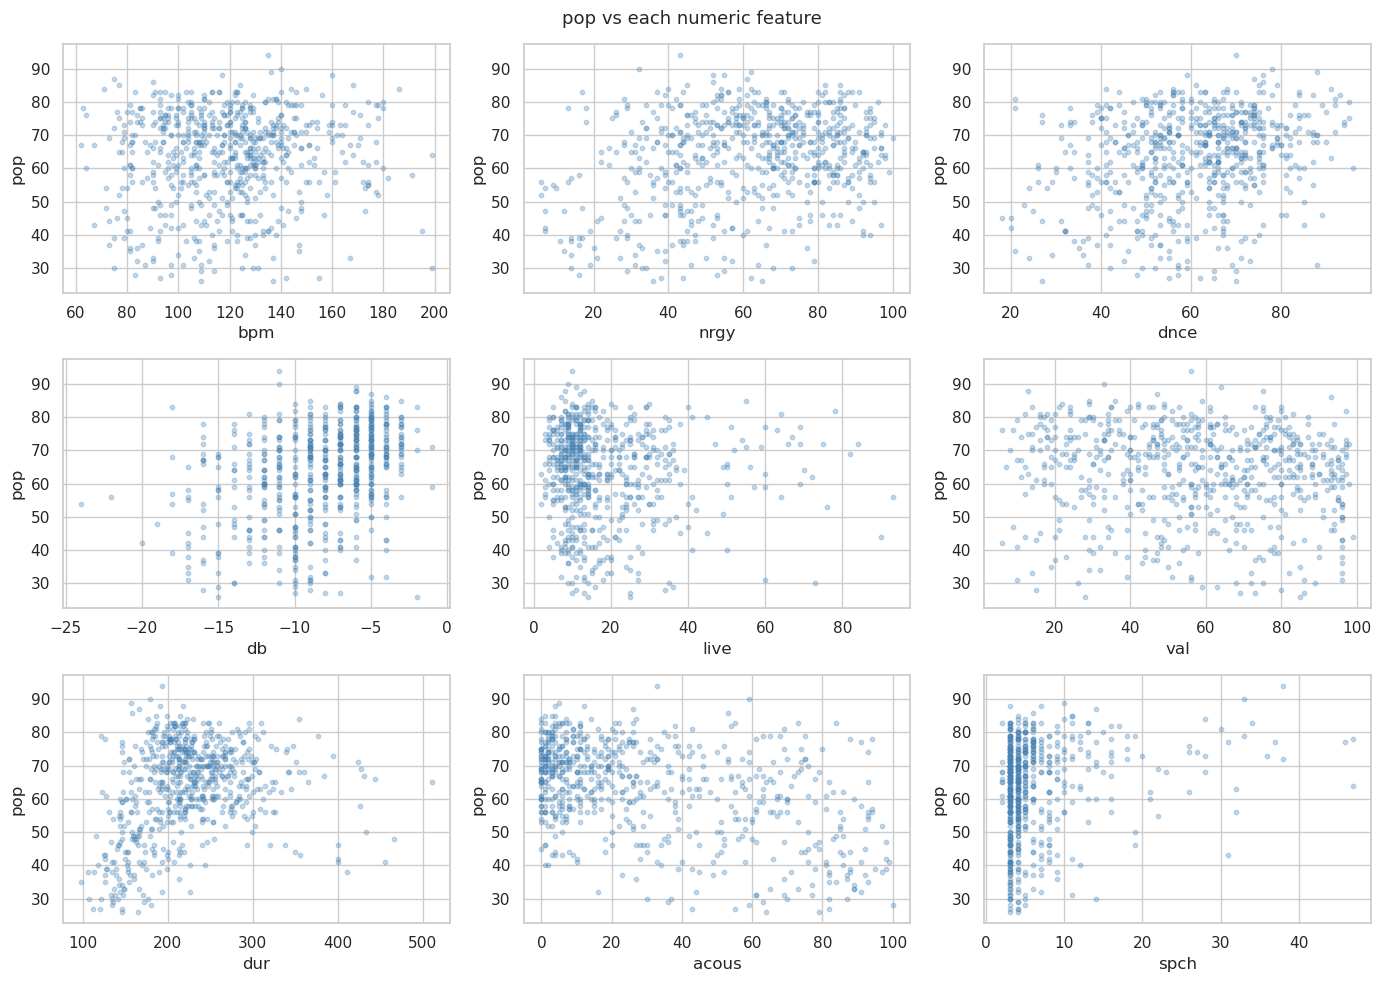

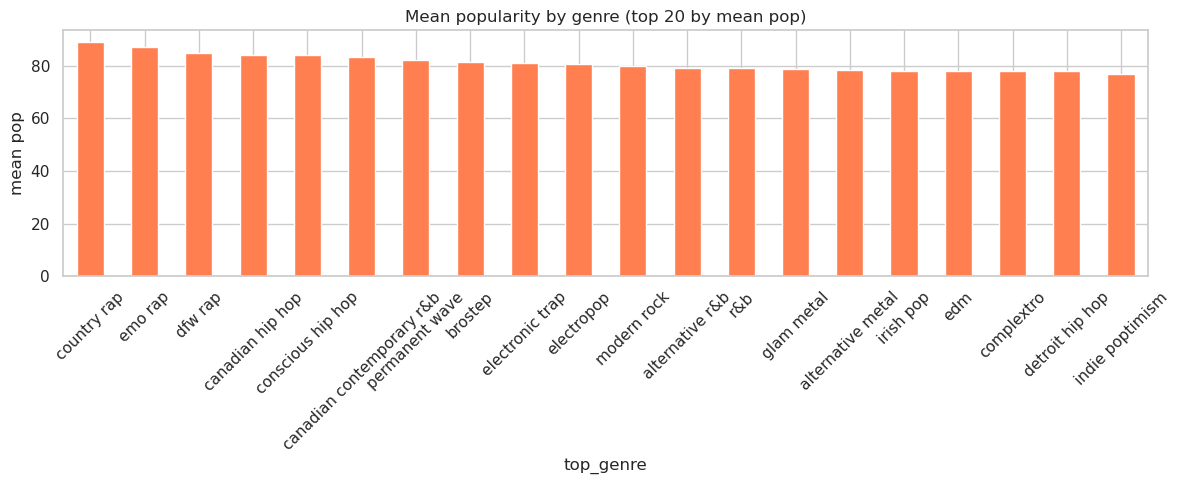

Top 15 genres by mean pop (with std and count):
                           mean   std  count
top_genre                                   
country rap                89.0   NaN      1
emo rap                    87.0   NaN      1
dfw rap                    84.8   2.2      5
canadian hip hop           84.0   1.4      2
conscious hip hop          84.0   NaN      1
canadian contemporary r&b  83.5   0.7      2
permanent wave             82.0   1.4      2
brostep                    81.5   2.1      2
electronic trap            81.0   NaN      1
electropop                 80.8  10.0      4
modern rock                80.0   5.6      3
alternative r&b            79.0   NaN      1
r&b                        79.0   NaN      1
glam metal                 78.7   5.1      3
alternative metal          78.3   6.4      3


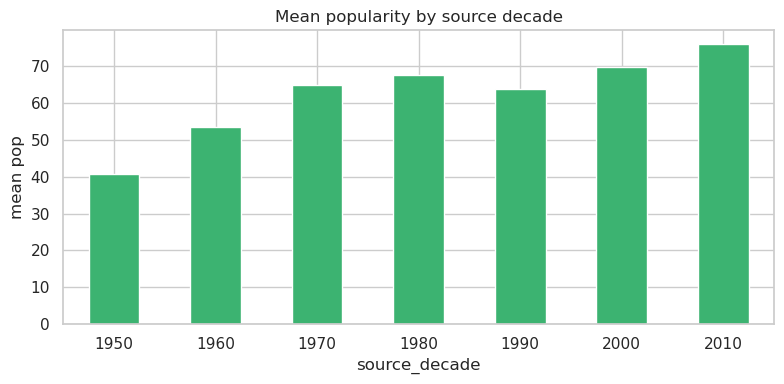

In [5]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[NUMERIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

print("Correlations with pop (sorted):")
print(corr["pop"].drop("pop").sort_values(ascending=False).round(3).to_string())

# ── pop vs each feature scatter ───────────────────────────────────────────────
feature_cols = [c for c in NUMERIC_COLS if c != TARGET]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, feature_cols):
    ax.scatter(df[col], df[TARGET], alpha=0.3, s=10, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("pop")
fig.suptitle("pop vs each numeric feature", fontsize=13)
plt.tight_layout()
plt.show()

# ── Mean pop by genre ─────────────────────────────────────────────────────────
genre_stats = df.groupby("top_genre")["pop"].agg(["mean", "std", "count"]).round(1)
top_genres = genre_stats.sort_values("mean", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 5))
top_genres["mean"].plot(kind="bar", ax=ax, color="coral", edgecolor="white")
ax.set_title("Mean popularity by genre (top 20 by mean pop)")
ax.set_ylabel("mean pop")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Top 15 genres by mean pop (with std and count):")
print(top_genres.head(15).to_string())

# ── Mean pop by decade ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
df.groupby("source_decade")["pop"].mean().plot(kind="bar", ax=ax,
    color="mediumseagreen", edgecolor="white")
ax.set_title("Mean popularity by source decade")
ax.set_ylabel("mean pop")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### Cleaning Decisions

Update this table after reviewing the outputs above, then run the cleaning cell.

| Issue | Decision | Justification |
| --- | --- | --- |
| Duplicate rows (same title + artist) | Drop, keep first | Prevents data leakage across train/holdout split |
| Year incoherence (re-releases) | Keep; add `is_rerelease` flag | Not enough data to afford dropping; flag lets the model use it |
| `pop == 0` rows | Drop | Likely a data error; a score of 0 is not meaningful on Spotify's scale |
| Rare genres (n < 3) | Collapse to `"other"` | Too sparse for meaningful target encoding |

In [6]:
df_clean = df.copy()

# Drop duplicates (same song shouldn't appear in both train and validation)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["title", "artist"]).reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} duplicate rows")

# Year coherence flag — keep rows but mark re-releases
df_clean["is_rerelease"] = ((df_clean["year"] - df_clean["source_decade"]).abs() > 15).astype(int)
print(f"Flagged {df_clean['is_rerelease'].sum()} re-releases (|year − source_decade| > 15)")

# Drop pop == 0 rows (data error, not a real popularity score)
pop0 = df_clean[df_clean["pop"] == 0]
if len(pop0):
    print(f"\npop == 0 rows being dropped:")
    print(pop0[["title", "artist", "top_genre", "year", "pop"]].to_string())
df_clean = df_clean[df_clean["pop"] > 0].reset_index(drop=True)
print(f"\nAfter dropping pop=0: {df_clean.shape}")

# Collapse rare genres into 'other'
MIN_GENRE_COUNT = 3
genre_freq = df_clean["top_genre"].value_counts()
rare_genres = genre_freq[genre_freq < MIN_GENRE_COUNT].index
df_clean["top_genre"] = df_clean["top_genre"].where(~df_clean["top_genre"].isin(rare_genres), "other")
print(f"Collapsed {len(rare_genres)} rare genres (n < {MIN_GENRE_COUNT}) → 'other'")
print(f"Unique genres remaining: {df_clean['top_genre'].nunique()}")

print(f"\nFinal clean shape: {df_clean.shape}")
df_clean[NUMERIC_COLS].describe().round(1)

Dropped 7 duplicate rows
Flagged 140 re-releases (|year − source_decade| > 15)

After dropping pop=0: (660, 16)
Collapsed 76 rare genres (n < 3) → 'other'
Unique genres remaining: 40

Final clean shape: (660, 16)


,bpm,nrgy,dnce,db,live,val,dur,acous,spch,pop
count,660.0,660.0,660.0,660.0,660.0,660.0,660.0,660.0,660.0,660.0
mean,119.2,61.4,60.4,-8.4,18.2,57.2,224.4,29.8,6.2,63.4
std,25.1,21.7,15.1,3.7,14.4,24.4,59.8,28.8,6.2,13.8
min,62.0,6.0,18.0,-24.0,2.0,6.0,98.0,0.0,2.0,26.0
25%,101.8,45.0,51.0,-10.2,9.0,38.0,185.8,6.0,3.0,56.0
50%,120.0,64.0,62.0,-8.0,13.0,58.0,218.0,19.0,4.0,66.0
75%,134.0,79.0,71.0,-6.0,24.0,78.0,254.2,52.0,6.0,74.0
max,199.0,100.0,96.0,-1.0,93.0,99.0,511.0,100.0,47.0,94.0


In [7]:
from sklearn.model_selection import train_test_split

HOLDOUT_DIR = Path("../../data/spotify-songs/validation")
HOLDOUT_DIR.mkdir(parents=True, exist_ok=True)

train_idx, holdout_idx = train_test_split(
    df_clean.index.tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df_clean["source_decade"],
)

df_train = df_clean.loc[train_idx].reset_index(drop=True)
df_holdout = df_clean.loc[holdout_idx].reset_index(drop=True)

with open(HOLDOUT_DIR / "holdout_indices.json", "w") as f:
    json.dump(holdout_idx, f)

print(f"Train:   {len(df_train)} rows ({len(df_train)/len(df_clean)*100:.1f}%)")
print(f"Holdout: {len(df_holdout)} rows ({len(df_holdout)/len(df_clean)*100:.1f}%)")
print(f"\nTrain decade distribution:")
print(df_train["source_decade"].value_counts().sort_index().to_string())
print(f"\nHoldout decade distribution:")
print(df_holdout["source_decade"].value_counts().sort_index().to_string())

Train:   594 rows (90.0%)
Holdout: 66 rows (10.0%)

Train decade distribution:
source_decade
1950    66
1960    85
1970    94
1980    93
1990    79
2000    90
2010    87

Holdout decade distribution:
source_decade
1950     7
1960     9
1970    10
1980    11
1990     9
2000    10
2010    10
